# 12 — CGM Daily Means × Food & Housing Insecurity

**Purpose**: Test whether food/housing insecurity (binary SDOH flag) is
associated with higher mean glucose, and whether this association interacts
with study group (i.e., does insecurity carry a larger glucose penalty for
people already managing diabetes on medications?).

Nearly half the cohort (≈49.5%) is food- or housing-insecure — this is a
primary equity lens on the dataset.

**Inputs**: `features_with_cluster.csv`  
**Output**: `data/processed/12_food_housing_insecurity_summary.csv`


In [1]:
import subprocess, sys
for pkg in ['scipy', 'seaborn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], capture_output=True)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}

# ── Mount Google Drive (persistent across independent kernels) ────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print('Environment ready.')

Mounted at /content/drive
Environment ready.


In [2]:
# ── 2. Load Features ─────────────────────────────────────────────────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')

# Derive study_group_label from code if missing (e.g. stale CSV from nb07)
if 'study_group_label' not in features.columns:
    features['study_group_label'] = features['study_group_code'].map(STUDY_GROUP_MAP)
features['study_group_label'] = pd.Categorical(
    features['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
features['insecurity_label'] = features['food_housing_insecurity'].map(
    {0: 'Food/Housing Secure', 1: 'Food/Housing Insecure'})

df = features.dropna(subset=['food_housing_insecurity', 'mean_glucose']).copy()
print(f'features: {features.shape}')
print(df['insecurity_label'].value_counts().to_string())
print(f'\nInsecurity rate: {df["food_housing_insecurity"].mean()*100:.1f}%')


features: (2245, 23)
insecurity_label
Food/Housing Insecure    1364
Food/Housing Secure       881

Insecurity rate: 60.8%


## 3. Distribution Analysis

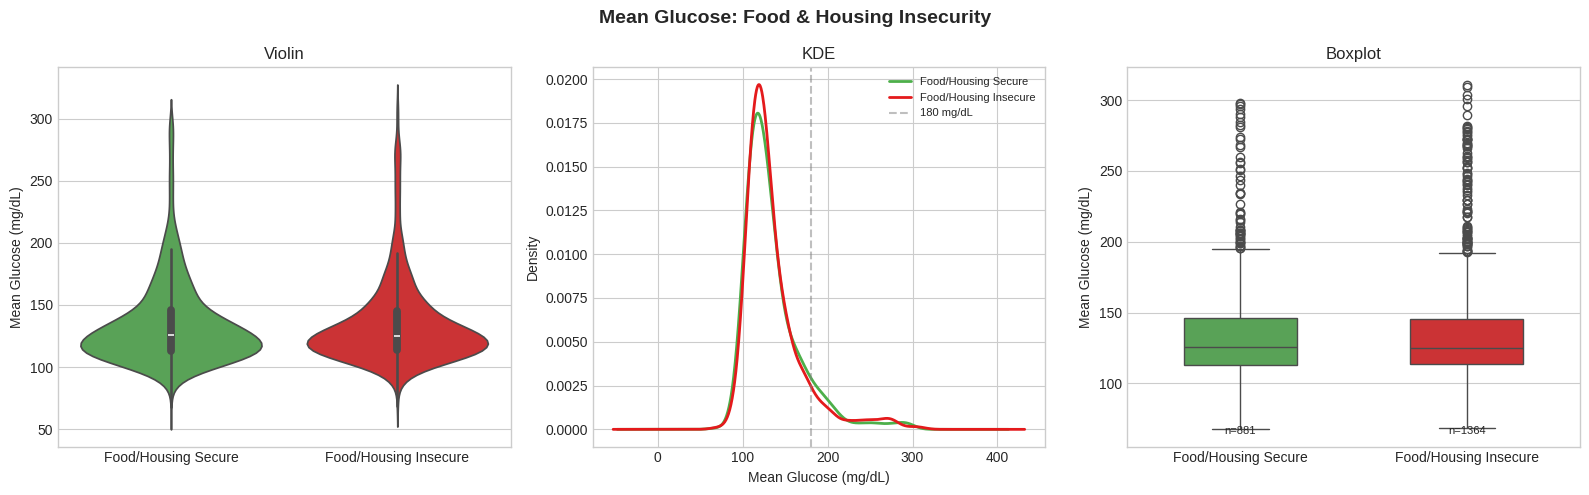

In [3]:
INSEC_ORDER = ['Food/Housing Secure', 'Food/Housing Insecure']
pal = {'Food/Housing Secure': '#4daf4a', 'Food/Housing Insecure': '#e41a1c'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mean Glucose: Food & Housing Insecurity', fontsize=14, fontweight='bold')

sns.violinplot(data=df, x='insecurity_label', y='mean_glucose',
               order=INSEC_ORDER, palette=pal, inner='box', ax=axes[0])
axes[0].set_title('Violin')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Glucose (mg/dL)')

for label in INSEC_ORDER:
    df[df['insecurity_label'] == label]['mean_glucose'].plot.kde(
        ax=axes[1], label=label, linewidth=2, color=pal[label])
axes[1].axvline(180, color='gray', linestyle='--', alpha=0.5, label='180 mg/dL')
axes[1].set_title('KDE')
axes[1].set_xlabel('Mean Glucose (mg/dL)')
axes[1].legend(fontsize=8)

sns.boxplot(data=df, x='insecurity_label', y='mean_glucose',
            order=INSEC_ORDER, palette=pal, width=0.5, ax=axes[2])
for i, label in enumerate(INSEC_ORDER):
    n = (df['insecurity_label'] == label).sum()
    axes[2].text(i, df['mean_glucose'].min() - 3, f'n={n}', ha='center', fontsize=8)
axes[2].set_title('Boxplot')
axes[2].set_xlabel('')
axes[2].set_ylabel('Mean Glucose (mg/dL)')

plt.tight_layout()
plt.show()


## 4. Primary Statistical Test

In [4]:
sec  = df[df['food_housing_insecurity'] == 0]['mean_glucose'].dropna()
insec = df[df['food_housing_insecurity'] == 1]['mean_glucose'].dropna()

u, p = stats.mannwhitneyu(sec, insec, alternative='two-sided')
d = (insec.mean() - sec.mean()) / np.sqrt((sec.std()**2 + insec.std()**2) / 2)
effect = 'small' if abs(d) < 0.5 else ('medium' if abs(d) < 0.8 else 'large')

print('=== Food/Housing Insecurity vs Mean Glucose ===')
print(f'Secure:   mean={sec.mean():.1f} SD={sec.std():.1f} n={len(sec):,}')
print(f'Insecure: mean={insec.mean():.1f} SD={insec.std():.1f} n={len(insec):,}')
print(f'Mann-Whitney U={u:.0f}  p={p:.4f}  Cohens d={d:+.3f} ({effect} effect)')


=== Food/Housing Insecurity vs Mean Glucose ===
Secure:   mean=135.2 SD=34.4 n=881
Insecure: mean=135.4 SD=34.9 n=1,364
Mann-Whitney U=596519  p=0.7732  Cohens d=+0.006 (small effect)


## 5. Interaction: Insecurity × Study Group

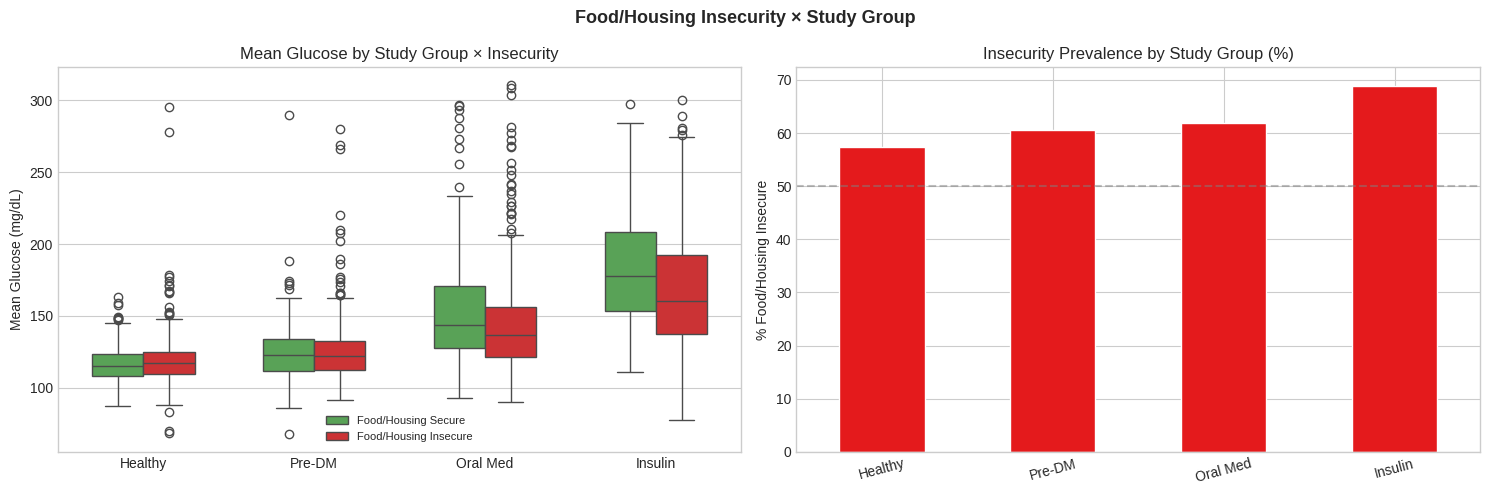

In [5]:
# ── 5a. Grouped boxplot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Food/Housing Insecurity × Study Group', fontsize=13, fontweight='bold')

sns.boxplot(data=df, x='study_group_label', y='mean_glucose',
            hue='insecurity_label', order=STUDY_GROUP_ORDER,
            hue_order=INSEC_ORDER, palette=pal, width=0.6, ax=axes[0])
axes[0].set_title('Mean Glucose by Study Group × Insecurity')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Glucose (mg/dL)')
axes[0].legend(title='', fontsize=8)

# Insecurity prevalence by study group
prev = (features.dropna(subset=['study_group_label'])
        .groupby('study_group_label', observed=True)['food_housing_insecurity']
        .mean() * 100)
prev.plot.bar(ax=axes[1], color=['#4daf4a' if v < 50 else '#e41a1c' for v in prev],
              edgecolor='white')
axes[1].set_title('Insecurity Prevalence by Study Group (%)')
axes[1].set_ylabel('% Food/Housing Insecure')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [6]:
# ── 5b. Within-group Mann-Whitney ────────────────────────────────────────
print('=== Within-group: Secure vs Insecure mean glucose ===\n')
print(f'{"Study Group":<12}  {"Secure":>8}  {"Insecure":>8}  {"diff":>7}  {"p":>8}  sig')
print('-' * 58)

for grp in STUDY_GROUP_ORDER:
    sub = df[df['study_group_label'] == grp]
    s   = sub[sub['food_housing_insecurity'] == 0]['mean_glucose'].dropna()
    i   = sub[sub['food_housing_insecurity'] == 1]['mean_glucose'].dropna()
    if len(s) > 5 and len(i) > 5:
        u, p = stats.mannwhitneyu(s, i, alternative='two-sided')
        diff = i.mean() - s.mean()
        sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{grp:<12}  {s.mean():>8.1f}  {i.mean():>8.1f}  {diff:>+7.1f}  {p:>8.4f}  {sig}')


=== Within-group: Secure vs Insecure mean glucose ===

Study Group     Secure  Insecure     diff         p  sig
----------------------------------------------------------
Healthy          116.3     119.2     +2.9    0.0217  *
Pre-DM           125.3     126.2     +0.9    0.6374  ns
Oral Med         152.2     144.5     -7.7    0.0005  ***
Insulin          184.5     171.6    -12.9    0.0120  *


## 6. Related SDOH Comparison

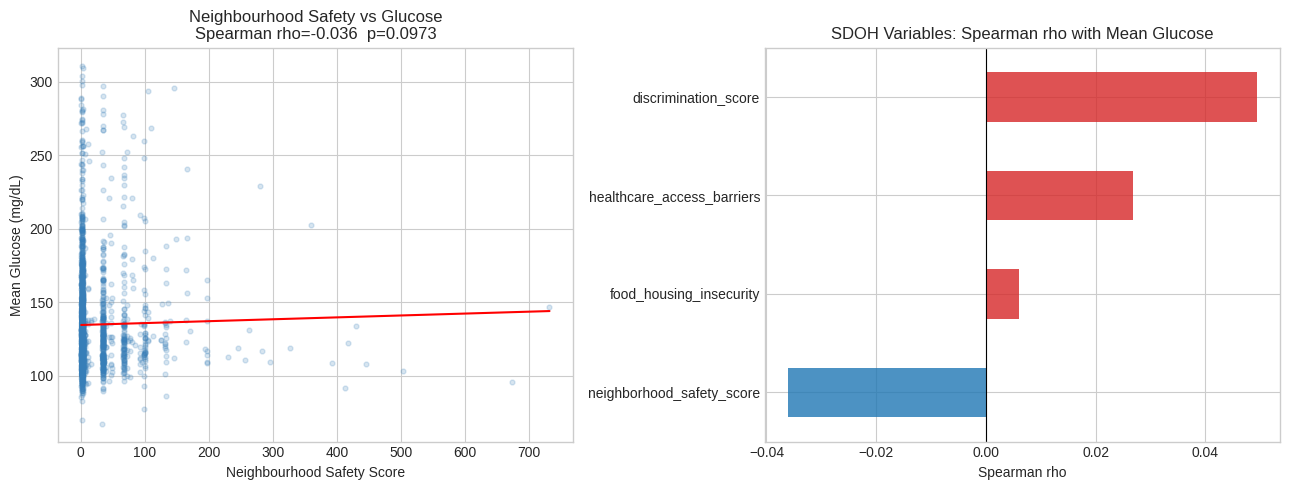

In [7]:
# ── 6. Side-by-side: food_housing_insecurity vs neighborhood_safety ───────
sdoh_cols = ['food_housing_insecurity', 'healthcare_access_barriers',
             'discrimination_score', 'neighborhood_safety_score']
available = [c for c in sdoh_cols if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: neighbourhood safety scatter (only if column exists)
if 'neighborhood_safety_score' in df.columns:
    ns_df = df[['neighborhood_safety_score', 'mean_glucose']].dropna()
    rho, p = stats.spearmanr(ns_df['neighborhood_safety_score'], ns_df['mean_glucose'])
    axes[0].scatter(ns_df['neighborhood_safety_score'], ns_df['mean_glucose'], alpha=0.2, s=12, color='#377eb8')
    m, b, *_ = stats.linregress(ns_df['neighborhood_safety_score'], ns_df['mean_glucose'])
    xs = np.linspace(ns_df['neighborhood_safety_score'].min(), ns_df['neighborhood_safety_score'].max(), 100)
    axes[0].plot(xs, m*xs + b, color='red', linewidth=1.5)
    axes[0].set_xlabel('Neighbourhood Safety Score')
    axes[0].set_ylabel('Mean Glucose (mg/dL)')
    axes[0].set_title(f'Neighbourhood Safety vs Glucose\nSpearman rho={rho:.3f}  p={p:.4f}')
else:
    axes[0].text(0.5, 0.5, 'neighborhood_safety_score\nnot in dataset',
                 ha='center', va='center', transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title('Neighbourhood Safety vs Glucose')
    print('Note: neighborhood_safety_score not in features CSV — skipping scatter.')

# Right: SDOH Spearman correlations bar chart
corrs = {}
for col in available:
    sub = df[[col, 'mean_glucose']].dropna()
    if len(sub) > 30:
        rho_i, p_i = stats.spearmanr(sub[col], sub['mean_glucose'])
        corrs[col] = rho_i

corr_s = pd.Series(corrs).sort_values()
corr_s.plot.barh(ax=axes[1], color=['#d62728' if v > 0 else '#1f77b4' for v in corr_s],
                 alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('SDOH Variables: Spearman rho with Mean Glucose')
axes[1].set_xlabel('Spearman rho')

plt.tight_layout()
plt.show()

## 7. Summary Table & Export

In [8]:
summary = (
    df.groupby('insecurity_label', observed=True)['mean_glucose']
    .agg(n='count', mean='mean', std='std', median='median',
         pct_gt_180=lambda x: (x > 180).mean() * 100)
    .round(2).reset_index()
)
summary.columns = ['Insecurity Status', 'N', 'Mean (mg/dL)', 'SD', 'Median', '% > 180 mg/dL']
print(summary.to_string(index=False))

summary.to_csv(out_dir / '12_food_housing_insecurity_summary.csv', index=False)
print('\nSaved 12_food_housing_insecurity_summary.csv')


    Insecurity Status    N  Mean (mg/dL)     SD  Median  % > 180 mg/dL
Food/Housing Insecure 1364       135.370 34.950 124.800          8.720
  Food/Housing Secure  881       135.170 34.400 125.410          9.530

Saved 12_food_housing_insecurity_summary.csv


## 8. Key Findings

- **No overall association**: At the cohort level, food/housing insecurity shows virtually no relationship with mean glucose — Secure: 135.2 mg/dL vs. Insecure: 135.4 mg/dL; Mann-Whitney p = 0.773, Cohen's d = +0.006 (negligible). The overall insecurity rate in this cohort is 60.8% (n=1,364 insecure).
- **Significant interaction with study group** — the direction of the insecurity effect reverses across disease severity:
  - *Healthy*: Insecure participants have slightly higher glucose (+2.9 mg/dL, p=0.022 *)
  - *Pre-DM*: No significant difference (+0.9 mg/dL, p=0.637 ns)
  - *Oral Med*: Insecure participants have notably **lower** glucose (−7.7 mg/dL, p=0.001 ***)
  - *Insulin*: Insecure participants have notably **lower** glucose (−12.9 mg/dL, p=0.012 *)
- **Reversal pattern**: The counter-intuitive negative association in medicated groups (Oral Med, Insulin) likely reflects selection or behavioral effects — e.g., food-insecure participants on medications may be more engaged with clinical management, or the insecurity flag captures a complex social profile that intersects differently with medication-managed disease.
- **Threshold exceedance**: Nearly identical between groups — Insecure: 8.7% of daily means > 180 mg/dL vs. Secure: 9.5%, consistent with the null overall finding.
- **Interpretation**: Food and housing insecurity does not have a simple, uniform effect on glycemic control in this cohort. Its impact is highly heterogeneous across disease stages, suggesting that SDOH equity analyses for this variable should be conducted within — not across — study groups.
